# TSA Claims Data Analysis
Jyteriyon Thomas 


## 1. Data Preparation

In [35]:

%pip install geopandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [37]:
pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
import pandas as pd

# Load data
claims = pd.read_csv('tsa_claims2.csv')

# Preview
claims.head()
claims.info()

<class 'pandas.DataFrame'>
RangeIndex: 204267 entries, 0 to 204266
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Claim Number   204267 non-null  object
 1   Date Received  204004 non-null  str   
 2   Incident Date  202084 non-null  str   
 3   Airport Code   195743 non-null  str   
 4   Airport Name   195743 non-null  str   
 5   Airline Name   169893 non-null  str   
 6   Claim Type     196354 non-null  str   
 7   Claim Site     203527 non-null  str   
 8   Item           200301 non-null  str   
 9   Claim Amount   200224 non-null  str   
 10  Status         204262 non-null  str   
 11  Close Amount   135315 non-null  str   
 12  Disposition    131359 non-null  str   
dtypes: object(1), str(12)
memory usage: 20.3+ MB


/tmp/ipykernel_35794/854403418.py:4: DtypeWarning: Columns (0: Claim Number, 1: Close Amount, 2: Disposition) have mixed types. Specify dtype option on import or set low_memory=False.
  claims = pd.read_csv('tsa_claims2.csv')


In [39]:
claims = pd.read_csv('tsa_claims2.csv', low_memory=False)

claims['Close Amount'] = claims['Close Amount'].astype(str)
claims['Claim Amount'] = claims['Claim Amount'].astype(str)

In [40]:

claims['Close Amount'] = claims['Close Amount'].astype(str)

claims['Close Amount'] = claims['Close Amount'].str.replace('$', '', regex=False)
claims['Close Amount'] = claims['Close Amount'].str.replace(',', '', regex=False)

claims['Close Amount'] = pd.to_numeric(claims['Close Amount'], errors='coerce')

In [41]:
claims['Claim Amount'] = claims['Claim Amount'].astype(str)
claims['Claim Amount'] = claims['Claim Amount'].str.replace('$', '', regex=False)
claims['Claim Amount'] = claims['Claim Amount'].str.replace(',', '', regex=False)
claims['Claim Amount'] = pd.to_numeric(claims['Claim Amount'], errors='coerce')

In [42]:
# Check missing values
claims.isna().sum()

# Drop rows missing critical info
claims = claims.dropna(subset=['Claim Type', 'Claim Site'])

# Fill numeric NaNs with 0
claims['Close Amount'] = claims['Close Amount'].fillna(0)

In [43]:
claims['Date Received'] = pd.to_datetime(
    claims['Date Received'],
    format='%m/%d/%Y',
    errors='coerce'
)

In [44]:
claims['Claim Type'] = claims['Claim Type'].str.strip().str.title()
claims['Claim Site'] = claims['Claim Site'].str.strip().str.title()

## 2. Data Analysis

Most common claim type

In [45]:
claims['Claim Type'].value_counts().head()

Claim Type
Passenger Property Loss    117689
Property Damage             75228
Personal Injury              1453
Employee Loss (Mpceca)        484
Passenger Theft               464
Name: count, dtype: int64

<Axes: xlabel='Claim Type'>

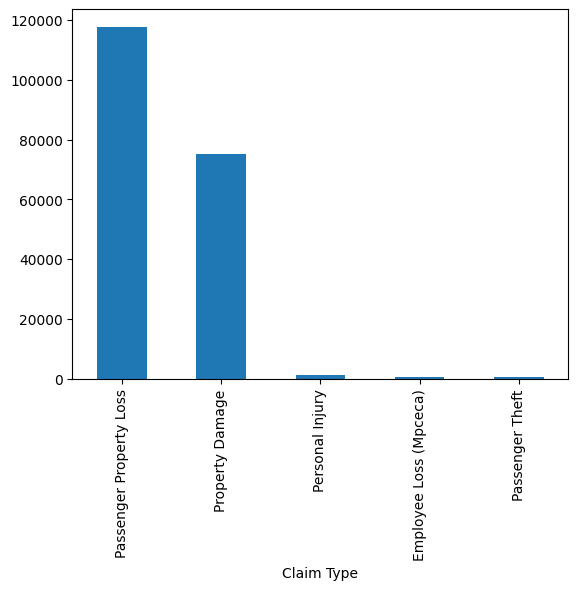

In [46]:
claims['Claim Type'].value_counts().head().plot(kind='bar')

Most common claim site 

In [47]:
claims['Claim Site'].value_counts()

Claim Site
Checked Baggage    154965
Checkpoint          39199
Other                1100
Motor Vehicle         468
-                     276
Bus Station            16
Name: count, dtype: int64

Most common claim type per site

In [48]:
pd.crosstab(claims['Claim Site'], claims['Claim Type'])

Claim Type,-,Bus Terminal,Complaint,Compliment,Employee Loss (Mpceca),Motor Vehicle,Passenger Property Loss,Passenger Theft,Personal Injury,Property Damage,Wrongful Death
Claim Site,,,,,,,,,,,
-,127,0,3,0,1,3,92,0,10,40,0
Bus Station,0,0,0,0,0,0,9,0,0,7,0
Checked Baggage,99,1,20,1,383,26,99708,396,248,54083,0
Checkpoint,49,0,21,2,66,9,17440,66,974,20572,0
Motor Vehicle,2,0,0,0,19,320,6,1,70,49,1
Other,5,0,4,0,15,10,434,1,151,477,3


Typical claim amount

In [49]:
claims['Close Amount'].describe()

count    196024.000000
mean         40.309125
std         109.074298
min           0.000000
25%           0.000000
50%           0.000000
75%          24.000000
max         999.990000
Name: Close Amount, dtype: float64

In [50]:
claims['Close Amount'].median()

np.float64(0.0)

Approval rate

In [51]:
claims['Disposition'].value_counts(normalize=True)

Disposition
Deny               0.528910
Approve in Full    0.265141
Settle             0.205949
Name: proportion, dtype: float64

In [52]:
approved = claims['Disposition'].isin(['Approved', 'Settled'])
approved.mean()

np.float64(0.0)

Percent of claims paid

In [55]:
claims['Claim Amount'] = pd.to_numeric(claims['Claim Amount'], errors='coerce')
claims['Close Amount'] = pd.to_numeric(claims['Close Amount'], errors='coerce')

claims['Percent Paid'] = claims['Close Amount'] / claims['Claim Amount']

In [56]:
claims.groupby('Claim Site')[['Claim Amount', 'Close Amount', 'Percent Paid']].mean().sort_values('Percent Paid', ascending=False)

,Claim Amount,Close Amount,Percent Paid
Claim Site,,,
Checked Baggage,164.927423,35.578318,inf
Checkpoint,195.887263,59.123710,0.397171
Motor Vehicle,466.136619,57.627671,0.352542
Other,202.080298,39.638045,0.317417
Bus Station,99.999000,0.000000,0.000000
-,22.811642,0.000000,0.000000


Top 5 airports

In [57]:
claims['Airport Code'].value_counts().head()

Airport Code
LAX    9207
JFK    9015
EWR    6643
ORD    6626
MIA    6201
Name: count, dtype: int64

Trends over time

In [58]:
claims['Year'] = pd.to_datetime(claims['Date Received'], format='mixed', errors='coerce').dt.year

<Axes: xlabel='Year'>

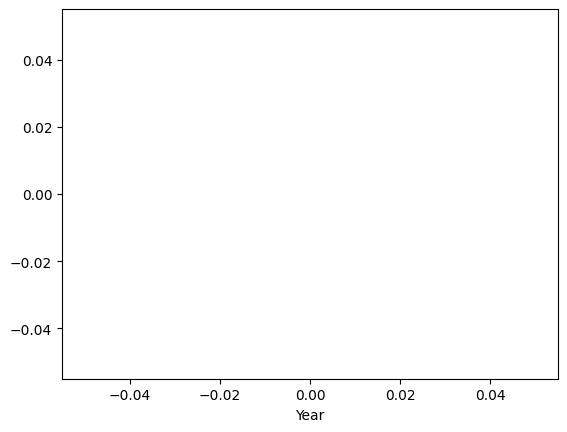

In [59]:
claims['Close Amount'] = pd.to_numeric(claims['Close Amount'], errors='coerce').fillna(0)
claims.groupby('Year')['Close Amount'].sum().plot()

GEOPANDAS MAP

/tmp/ipykernel_35794/692881034.py:9: DtypeWarning: Columns (0: Claim Number, 1: Close Amount, 2: Disposition) have mixed types. Specify dtype option on import or set low_memory=False.
  claims = pd.read_csv("tsa_claims2.csv")


<Axes: >

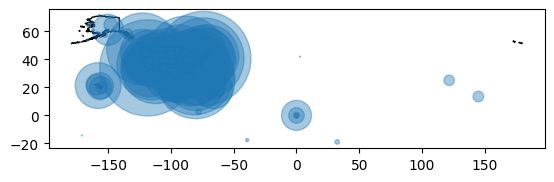

In [ ]:
import pandas as pd
import geopandas as gpd
import zipfile
import os

with zipfile.ZipFile("maps.zip", "r") as z:
    z.extractall("maps")

claims = pd.read_csv("tsa_claims2.csv")
airports = pd.read_csv("GlobalAirportDatabase.csv")

airports = airports[['IATACode', 'LatitudeDecimalDegrees', 'LongitudeDecimalDegrees']].dropna()

claims['Close Amount'] = pd.to_numeric(claims['Close Amount'], errors='coerce').fillna(0)

merged = claims.merge(
    airports,
    left_on='Airport Code',
    right_on='IATACode',
    how='inner'
)

airport_counts = merged.groupby(
    ['IATACode', 'LatitudeDecimalDegrees', 'LongitudeDecimalDegrees']
).size().reset_index(name='Claims')

gdf = gpd.GeoDataFrame(
    airport_counts,
    geometry=gpd.points_from_xy(
        airport_counts['LongitudeDecimalDegrees'],
        airport_counts['LatitudeDecimalDegrees']
    ),
    crs="EPSG:4326"
)

states = gpd.read_file('https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip').to_crs("EPSG:4326")

ax = states.plot(color="white", edgecolor="black")

gdf.plot(
    ax=ax,
    markersize=airport_counts['Claims'] * 0.5,
    alpha=0.4
)